In [5]:
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from torchvision import datasets, transforms

from IPython.display import Image as IPImage, display
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import os, re, shutil, glob, time
from tqdm import tqdm

# VAE vs VAE & perceptual loss vs VQ-VAE

in this notebook we will compare the models in anime faces generation !
this notebook trains each model, end-to-end from scratch on ~48k anime faces, in 128x128, some samples:


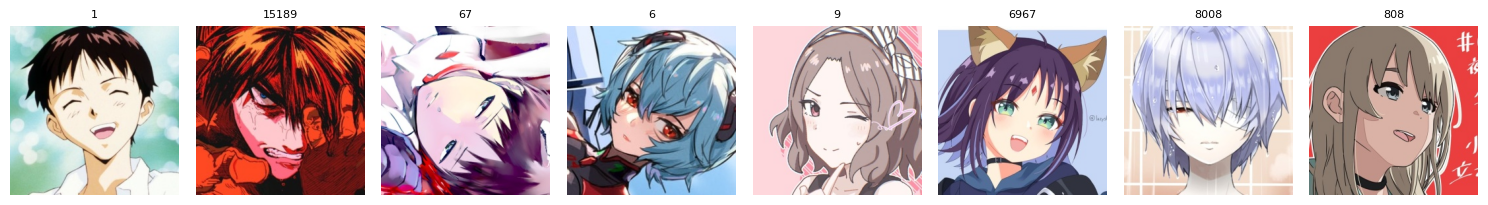

## Autoencoders
first, to understand the motivation behind VAEs we need to check our older method, let's train autoencoders on MNIST and try to observe why we need VAEs


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load MNIST
tf = transforms.ToTensor()  # scales pixels to [0, 1]
print("loading data...")
train = datasets.MNIST(root="./data", train=True, download=True, transform=tf)
loader = DataLoader(train, batch_size=256, shuffle=True)

# --- Model ---
class Autoencoder(nn.Module):
    def __init__(self, latent=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),    # 28 -> 14
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),   # 14 -> 7
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(), # 7 -> 4
            nn.Flatten(), nn.Linear(128 * 4 * 4, latent), nn.Sigmoid(),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent, 128 * 4 * 4), nn.ReLU(), nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=0),
            nn.BatchNorm2d(64), nn.ReLU(),  # 4 -> 7
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),  # 7 -> 14
            nn.ConvTranspose2d(32, 1, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(1), nn.Sigmoid(), # 14 -> 28
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

model = Autoencoder(latent=8).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

EPOCHS = 20
print("Training")
for epoch in range(EPOCHS):
    total = 0.0
    for x, _ in loader:
        x = x.to(device)

        recon = model(x)
        loss = loss_fn(recon, x)

        opt.zero_grad()
        loss.backward()
        opt.step()
        total += loss.item() * x.size(0)
    print(f"epoch {epoch + 1}/{EPOCHS}  loss={total / len(train):.4f}")

loading data...
Training
epoch 1/20  loss=0.1456
epoch 2/20  loss=0.0989
epoch 3/20  loss=0.0746
epoch 4/20  loss=0.0588
epoch 5/20  loss=0.0483
epoch 6/20  loss=0.0410
epoch 7/20  loss=0.0357
epoch 8/20  loss=0.0319
epoch 9/20  loss=0.0288
epoch 10/20  loss=0.0265
epoch 11/20  loss=0.0247
epoch 12/20  loss=0.0232
epoch 13/20  loss=0.0220
epoch 14/20  loss=0.0209
epoch 15/20  loss=0.0201
epoch 16/20  loss=0.0194
epoch 17/20  loss=0.0188
epoch 18/20  loss=0.0182
epoch 19/20  loss=0.0176
epoch 20/20  loss=0.0173


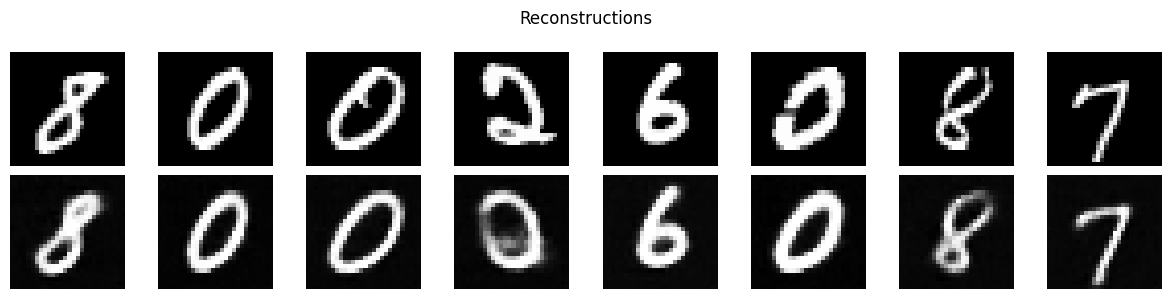

In [ ]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    x, _ = next(iter(loader))
    x = x[:8].to(device)
    recon = model(x).cpu()
    x = x.cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(x[i].squeeze(), cmap="gray");     axes[0, i].axis("off")
    axes[1, i].imshow(recon[i].squeeze(), cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_ylabel("original", rotation=0, ha="right", labelpad=30)
axes[1, 0].set_ylabel("recon", rotation=0, ha="right", labelpad=30)
plt.suptitle("Reconstructions")
plt.tight_layout(); plt.savefig("reconstructions.png"); plt.show()

##### Question: How come some images look great but others don't ... ??
(hint: notice how reconstructions always look ~good but in generation we sometimes end up with gibbrish)

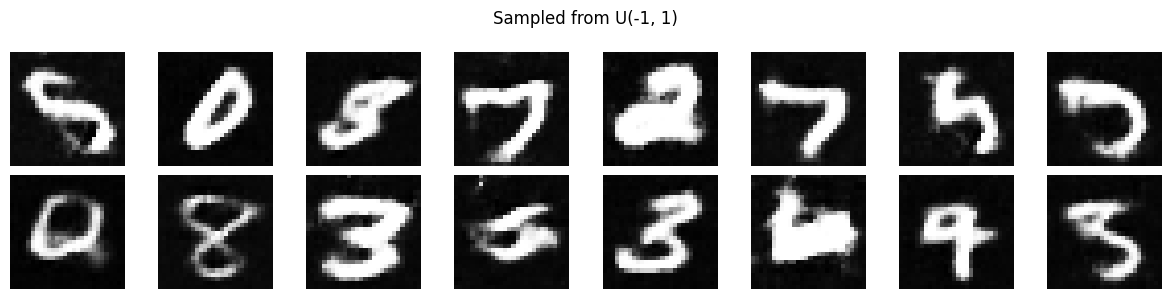

In [ ]:
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    zs = torch.rand(16, 8, device=device)    # uniform in [0, 1]
    gen = model.decoder(zs).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for img, ax in zip(gen, axes.flat):
    ax.imshow(img.squeeze(), cmap="gray"); ax.axis("off")
plt.suptitle("Sampled from U(0, 1)")
plt.tight_layout(); plt.savefig("generated.png"); plt.show()

## Data Loading

In [3]:
import kagglehub
import os
# Download the dataset from Kaggle
path = kagglehub.dataset_download("soumikrakshit/anime-faces")
print("Path to dataset files:", path)

# The dataset path will be the downloaded path
dataset_path = os.path.join(path,'data')

Path to dataset files: /root/.cache/kagglehub/datasets/soumikrakshit/anime-faces/versions/1


In [6]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class AnimeFacesDataset(Dataset):
    def __init__(self, root_dir, transform=None, img_size=128):
        self.root_dir = root_dir
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
        ])
        self.image_files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image

In [7]:

# Create dataset and dataloader
anime_dataset = AnimeFacesDataset(root_dir=dataset_path)


In [8]:
from sklearn.model_selection import train_test_split

# Get indices for split
indices = list(range(len(anime_dataset)))
train_indices, val_indices = train_test_split(indices, test_size=0.1, random_state=42)

# Create subsets using torch.utils.data.Subset
from torch.utils.data import Subset
train_ds = Subset(anime_dataset, train_indices)
val_ds = Subset(anime_dataset, val_indices)

print(f"Total images: {len(anime_dataset)}")
print(f"Training set size: {len(train_ds)}")
print(f"Validation set size: {len(val_ds)}")

Total images: 21551
Training set size: 19395
Validation set size: 2156


In [9]:
# Initialize DataLoaders
batch_size = 64
num_workers = os.cpu_count()

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

print(f"DataLoaders created with batch size {batch_size} and {num_workers} workers.")

DataLoaders created with batch size 64 and 48 workers.


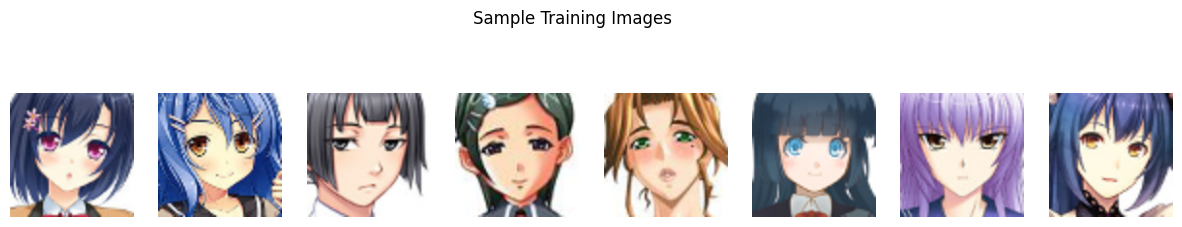

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch from the training loader
data_iter = iter(train_loader)
images = next(data_iter)

# Plot the first 8 images
n = 8
fig, axes = plt.subplots(1, n, figsize=(15, 3))
for i in range(n):
    # permute from (C, H, W) to (H, W, C) for plotting
    img = images[i].permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].axis('off')

plt.suptitle('Sample Training Images')
plt.show()

## The VAE model
The architecture we're implementing:

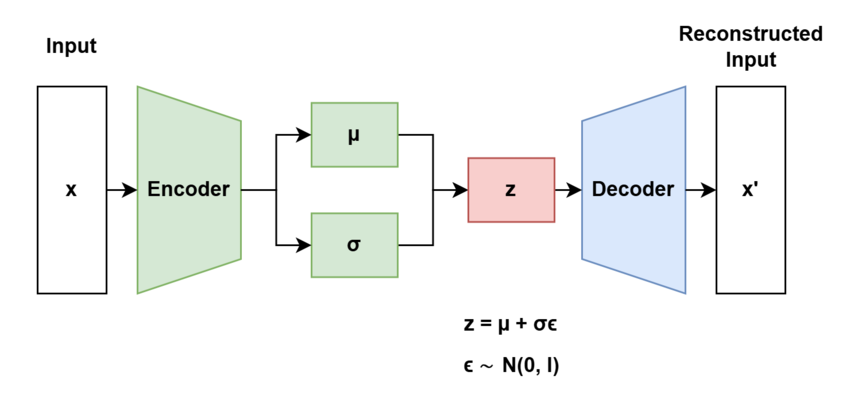

our componants structure:
### VAE Dataflow Architecture

```text
[Input Image] (Shape: [Batch, 3, 128, 128])
      │
      ▼
┌────────────────────────────────────────────────────────┐
│ 1. ENCODER (self.encoder)                              │
│    • _down(3, 32)     ──► Shape: [Batch, 32, 64, 64]   │
│    • _down(32, 64)    ──► Shape: [Batch, 64, 32, 32]   │
│    • _down(64, 128)   ──► Shape: [Batch, 128, 16, 16]  │
│    • _down(128, 256)  ──► Shape: [Batch, 256, 8, 8]    │
│    • _down(256, 512)  ──► Shape: [Batch, 512, 4, 4]    │
│    • nn.Flatten()     ──► Shape: [Batch, 8192]         │
└─────────────────────┬──────────────────────────────────┘
                      │
            ┌─────────┴─────────┐ (Splits into two paths)
            ▼                   ▼
┌──────────────────────┐  ┌──────────────────────┐
│  2. MU PATH          │  │  3. LOGVAR PATH      │
│  self.fc_mu(h)       │  │  self.fc_logvar(h)   │
│                      │  │  torch.clamp(-10,10) │
└───────────┬──────────┘  └───────────┬──────────┘
            │ [Batch, latent]         │ [Batch, latent]
            ▼                         ▼
┌────────────────────────────────────────────────────────┐
│ 4. REPARAMETERIZATION TRICK (self.reparameterize)      │
│    • Sample eps ~ N(0, I)                              │
│    • std = exp(0.5 * logvar)                           │
│    • z = mu + eps * std                                │
└─────────────────────┬──────────────────────────────────┘
                      │
                      ▼ Latent Vector 'z' (Shape: [Batch, latent])
┌────────────────────────────────────────────────────────┐
│ 5. DECODER PREP (self.decode)                          │
│    • self.fc_dec(z)   ──► Shape: [Batch, 8192]         │
│    • .view()          ──► Shape: [Batch, 512, 4, 4]    │
└─────────────────────┬──────────────────────────────────┘
                      │
                      ▼
┌────────────────────────────────────────────────────────┐
│ 6. DECODER (self.decoder)                              │
│    • _up(512, 256)    ──► Shape: [Batch, 256, 8, 8]    │
│    • _up(256, 128)    ──► Shape: [Batch, 128, 16, 16]  │
│    • _up(128, 64)     ──► Shape: [Batch, 64, 32, 32]   │
│    • _up(64, 32)      ──► Shape: [Batch, 32, 64, 64]   │
│    • ConvTranspose2d  ──► Shape: [Batch, 3, 128, 128]  │
│    • nn.Sigmoid()     ──► Pixels scaled between 0 and 1│
└─────────────────────┬──────────────────────────────────┘
                      │
                      ▼
[Reconstructed Image] (Shape: [Batch, 3, 128, 128])

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, latent=256):
        super().__init__()
        self.latent = latent

        # --- Encoder: 128 -> 64 -> 32 -> 16 -> 8 -> 4 ---
        self.encoder = nn.Sequential(
            self._down(3, 32),     # 128 -> 64
            self._down(32, 64),    # 64  -> 32
            self._down(64, 128),   # 32  -> 16
            self._down(128, 256),  # 16  -> 8
            self._down(256, 512),  # 8   -> 4
            nn.Flatten(),
        )
        self.fc_mu     = nn.Linear(512 * 4 * 4, latent)
        self.fc_logvar = nn.Linear(512 * 4 * 4, latent)

        # --- Decoder: 4 -> 8 -> 16 -> 32 -> 64 -> 128 ---
        self.fc_dec = nn.Linear(latent, 512 * 4 * 4)
        self.decoder = nn.Sequential(
            self._up(512, 256),   # 4  -> 8
            self._up(256, 128),   # 8  -> 16
            self._up(128, 64),    # 16 -> 32
            self._up(64, 32),     # 32 -> 64
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),  # 64 -> 128
            nn.Sigmoid(),
        )

    @staticmethod
    def _down(cin, cout):
        return nn.Sequential(
            nn.Conv2d(cin, cout, 3, stride=2, padding=1),
            nn.BatchNorm2d(cout),
            nn.LeakyReLU(0.2, inplace=True),
        )

    @staticmethod
    def _up(cin, cout):
        return nn.Sequential(
            nn.ConvTranspose2d(cin, cout, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(cout),
            nn.LeakyReLU(0.2, inplace=True),
        )

    def encode(self, x):
      h = self.encoder(x)
      logvar = torch.clamp(self.fc_logvar(h), -10, 10)   # exp(10) is the ceiling
      return self.fc_mu(h), logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z).view(-1, 512, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

### Training code

In [12]:
def vae_loss(recon, x, mu, logvar, beta=1.0):
    # reconstruction: summed over pixels, averaged over batch
    recon_loss = F.mse_loss(recon, x, reduction="sum") / x.size(0)
    # KL divergence to N(0, I)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + beta * kld, recon_loss, kld

In [13]:
from tqdm import tqdm
import torch

def train_one_epoch(model, loader, optimizer, device, beta=1.0):
    model.train()
    totals = {"loss": 0.0, "recon": 0.0, "kld": 0.0}
    n = 0

    pbar = tqdm(loader, desc="train", leave=False)
    for x in pbar:
        x = x.to(device)
        recon, mu, logvar = model(x)
        loss, recon_l, kld = vae_loss(recon, x, mu, logvar, beta)


        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
        optimizer.step()

        bs = x.size(0)
        totals["loss"]  += loss.item()    * bs
        totals["recon"] += recon_l.item() * bs
        totals["kld"]   += kld.item()     * bs

        n += bs
        pbar.set_postfix(loss=loss.item(), kld=kld.item())

    return {k: v / n for k, v in totals.items()}

@torch.no_grad()
def eval_one_epoch(model, loader, device, beta=1.0):
    model.eval()
    totals = {"loss": 0.0, "recon": 0.0, "kld": 0.0}
    n = 0

    pbar = tqdm(loader, desc="eval", leave=False)
    for x in pbar:
        x = x.to(device)
        recon, mu, logvar = model(x)
        loss, recon_l, kld = vae_loss(recon, x, mu, logvar, beta)

        bs = x.size(0)
        totals["loss"]  += loss.item()    * bs
        totals["recon"] += recon_l.item() * bs
        totals["kld"]   += kld.item()     * bs
        n += bs
        pbar.set_postfix(loss=loss.item())

    return {k: v / n for k, v in totals.items()}

In [ ]:
EPOCHS = 30
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
history = {"train": [], "val": []}

VAE_model = VAE(latent=128 + 64).to(device)
optimizer = torch.optim.Adam(VAE_model.parameters(), lr=1e-3)

# optional
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

BETA = 0.75 # normal VAE for now ...

for epoch in range(1, EPOCHS + 1):
    train_stats = train_one_epoch(VAE_model, train_loader, optimizer, device, beta=BETA)
    val_stats   = eval_one_epoch(VAE_model, val_loader, device, beta=BETA)
    history["train"].append(train_stats); history["val"].append(val_stats)

    scheduler.step()

    print(
        f"epoch {epoch:2d}/{EPOCHS} | "
        f"train loss {train_stats['loss']:.1f} "
        f"(recon {train_stats['recon']:.1f}, kld {train_stats['kld']:.1f}) | "
        f"val loss {val_stats['loss']:.1f}"
    )

torch.save(VAE_model.state_dict(), "vae_anime.pth")
print("saved -> vae_anime.pth")

epoch  1/30 | train loss 1965.2 (recon 1816.7, kld 198.0) | val loss 1252.2


epoch  2/30 | train loss 1109.1 (recon 972.4, kld 182.3) | val loss 1029.6


epoch  3/30 | train loss 981.2 (recon 837.2, kld 192.1) | val loss 935.4


epoch  4/30 | train loss 917.0 (recon 768.2, kld 198.4) | val loss 882.7


epoch  5/30 | train loss 879.4 (recon 726.3, kld 204.2) | val loss 859.8


...

epoch 26/30 | train loss 737.0 (recon 571.7, kld 220.3) | val loss 751.2


epoch 27/30 | train loss 735.8 (recon 570.5, kld 220.4) | val loss 737.3


epoch 28/30 | train loss 733.7 (recon 568.2, kld 220.6) | val loss 742.5


epoch 29/30 | train loss 732.5 (recon 567.0, kld 220.6) | val loss 735.6


epoch 30/30 | train loss 731.3 (recon 565.8, kld 220.7) | val loss 732.8
saved -> vae_anime.pth


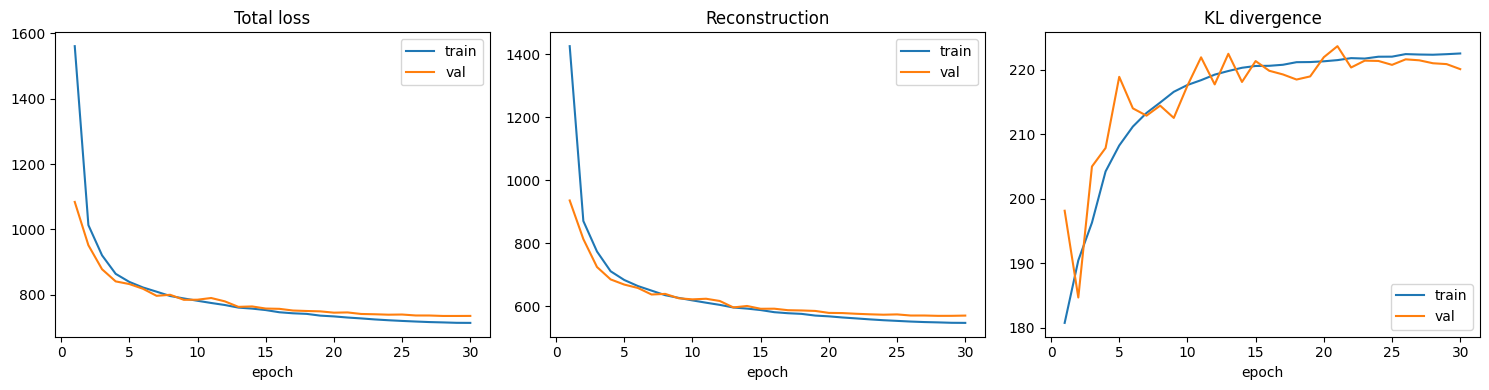

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train"]) + 1)
tr = history["train"]
va = history["val"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ["loss", "recon", "kld"],
                          ["Total loss", "Reconstruction", "KL divergence"]):
    ax.plot(epochs, [d[key] for d in tr], label="train")
    ax.plot(epochs, [d[key] for d in va], label="val")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout(); plt.savefig("vae_curves.png"); plt.show()

### Generation

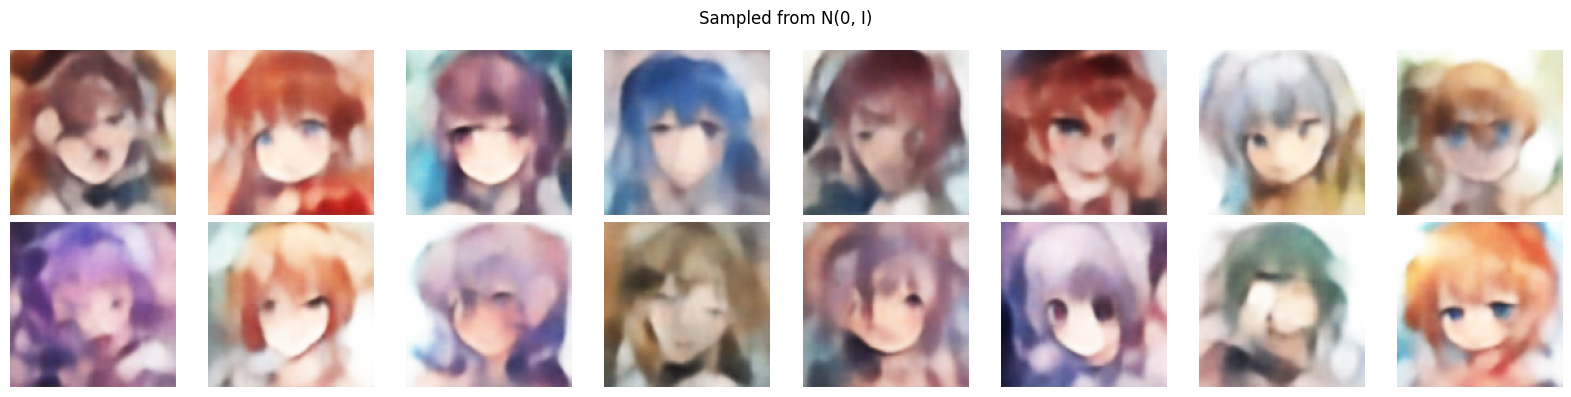

In [ ]:
import matplotlib.pyplot as plt

model.eval()
n = 16
with torch.no_grad():
    z = torch.randn(n, VAE_model.latent, device=device)+0.1    # sample the prior
    gen = VAE_model.decode(z).cpu()                        # (n, 3, 128, 128) in [0,1]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for img, ax in zip(gen, axes.flat):
    ax.imshow(img.permute(1, 2, 0))   # CHW -> HWC for RGB
    ax.axis("off")
plt.suptitle("Sampled from N(0, I)")
plt.tight_layout(); plt.savefig("vae_samples.png"); plt.show()

#### Bonus cell


Well, KL divergence is ~220, meaning the latents aren't actually a standard normal distribution (mean=0, std=1), so we shouldn't really sample from N(0,1) and we should sample from the actual mean and std of data

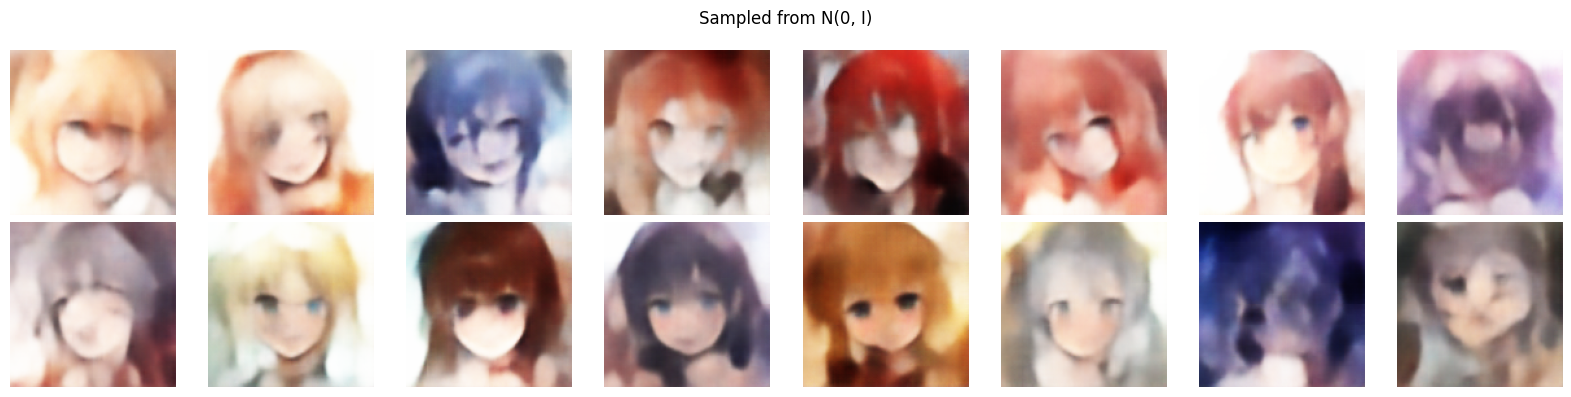

In [ ]:
import numpy as np

VAE_model.eval()
mus = []
with torch.no_grad():
    for x in train_loader:
        mu, _ = VAE_model.encode(x.to(device))
        mus.append(mu.cpu())
mus = torch.cat(mus, 0).numpy()          # (N, latent)

# --- full-covariance Gaussian fit ---
mean = torch.tensor(mus.mean(0), dtype=torch.float32)
cov  = torch.tensor(np.cov(mus, rowvar=False), dtype=torch.float32)
cov += 1e-4 * torch.eye(cov.size(0))     # jitter for numerical stability

dist = torch.distributions.MultivariateNormal(mean, covariance_matrix=cov)
with torch.no_grad():
    z = dist.sample((16,)).to(device)
    gen = VAE_model.decode(z).cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for img, ax in zip(gen, axes.flat):
    ax.imshow(img.permute(1, 2, 0))   # CHW -> HWC for RGB
    ax.axis("off")
plt.suptitle("Sampled from N(0, I)")
plt.tight_layout(); plt.savefig("vae_samples.png"); plt.show()

So it was kinda bad ...
but to get a better model, we need to ask, where did it actually go wrong?
two things are wrong with this current set up,
- "The averaging problem"
- "The hole problem"
so how do we do better

## VAE with perceptual loss

to make images sharper, we can try changing our loss function slightly to reward sharper images ..

the idea is simple:
- Run ground truth image, and reconstructed image to the VGG16, the VGG16 is trained to extract features, compare the real features and edges to the generated ones, this forces the model to produces sharper images !

```text
               Input Image
                    │
                    ▼
 ┌──────────────────────────────────────┐
 │               vgg[:4]                │ ──► Low-level features
 └──────────────────┬───────────────────┘
                    │ (Intermediate Output 1)
                    ▼
 ┌──────────────────────────────────────┐
 │               vgg[4:9]               │ ──► Mid-level features
 └──────────────────┬───────────────────┘
                    │ (Intermediate Output 2)
                    ▼
 ┌──────────────────────────────────────┐
 │              vgg[9:16]               │ ──► High-level features
 └──────────────────────────────────────┘

In [ ]:
# # just to see the actual layers:
# from torchvision.models import vgg16, VGG16_Weights

# vgg16(weights=VGG16_Weights.DEFAULT)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import vgg16, VGG16_Weights

class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = vgg16(weights=VGG16_Weights.DEFAULT).features.eval()
        for p in vgg.parameters():
            p.requires_grad_(False)

        # slices ending at relu1_2, relu2_2, relu3_3
        self.blocks = nn.ModuleList([vgg[:4], vgg[4:9], vgg[9:16]])
        # ImageNet normalization as buffers so .to(device) moves them
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def _norm(self, x):
        return (x - self.mean) / self.std

    def forward(self, recon, target):
        r, t = self._norm(recon), self._norm(target)
        loss = 0.0
        for block in self.blocks:
            r, t = block(r), block(t)
            loss = loss + F.mse_loss(r, t, reduction="sum") / r.size(0)  # per-image
        return loss

### Another train one epoch and validation one epoch

In [ ]:

from tqdm import tqdm
import torch

def train_one_epoch_perceptual(model, loader, optimizer, device, beta=1.0):
    model.train()
    totals = {"loss": 0.0, "recon": 0.0, "kld": 0.0, "percep":0.0}
    n = 0

    pbar = tqdm(loader, desc="train", leave=False)
    for x in pbar:
        x = x.to(device)
        recon, mu, logvar = model(x)
        loss, recon_l, kld, percep = vae_perceptual_loss(recon, x, mu, logvar, perceptual_fn, beta=beta)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        totals["loss"]  += loss.item()    * bs
        totals["recon"] += recon_l.item() * bs
        totals["kld"]   += kld.item()     * bs
        totals['percep']+= percep.item()  * bs

        n += bs
        pbar.set_postfix(loss=loss.item(), kld=kld.item())

    return {k: v / n for k, v in totals.items()}

@torch.no_grad()
def eval_one_epoch_perceptual(model, loader, device, beta=1.0):
    model.eval()
    totals = {"loss": 0.0, "recon": 0.0, "kld": 0.0, "percep":0.0}
    n = 0

    pbar = tqdm(loader, desc="eval", leave=False)
    for x in pbar:
        x = x.to(device)
        recon, mu, logvar = model(x)
        loss, recon_l, kld, percep = vae_perceptual_loss(recon, x, mu, logvar, perceptual_fn, beta=beta)

        bs = x.size(0)
        totals["loss"]  += loss.item()    * bs
        totals["recon"] += recon_l.item() * bs
        totals["kld"]   += kld.item()     * bs
        totals['percep']+= percep.item()  * bs
        n += bs
        pbar.set_postfix(loss=loss.item())

    return {k: v / n for k, v in totals.items()}

### Training with perceptual loss

In [ ]:
def vae_perceptual_loss(recon, x, mu, logvar, perceptual_fn,
             beta=10, pixel_w=1, percep_w=0.0001):
    pixel = F.mse_loss(recon, x, reduction="sum") / x.size(0)
    percep = perceptual_fn(recon, x)

    recon_loss = pixel_w * pixel + percep_w * percep
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + beta * kld, recon_loss, kld, percep

In [ ]:
EPOCHS = 40
perceptual_fn = PerceptualLoss().to(device)   # build once, before training
history = {"train": [], "val": []}

VAE_prcep_model = VAE(latent=256).to(device)
optimizer = torch.optim.AdamW(VAE_prcep_model.parameters(), lr=1e-3)

# optional
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

BETA = 1 # normal VAE for now ...

for epoch in range(1, EPOCHS + 1):
    train_stats = train_one_epoch_perceptual(VAE_prcep_model, train_loader, optimizer, device, beta=BETA)
    val_stats   = eval_one_epoch_perceptual(VAE_prcep_model, val_loader, device, beta=BETA)
    history["train"].append(train_stats); history["val"].append(val_stats)

    scheduler.step()

    print(
        f"epoch {epoch:2d}/{EPOCHS} | "
        f"train loss {train_stats['loss']:.1f} "
        f"(recon {train_stats['recon']:.1f}, kld {train_stats['kld']:.1f}, precep:{train_stats['percep']:.1f}) | "
        f"val loss {val_stats['loss']:.1f}"
    )

torch.save(VAE_prcep_model.state_dict(), "VAE_prcep_model.pth")
print("saved -> VAE_prcep_model.pth")

epoch  1/40 | train loss 2990.5 (recon 2826.8, kld 163.7, precep:12178460.3) | val loss 2342.3


epoch  2/40 | train loss 2247.6 (recon 2077.4, kld 170.3, precep:11406529.3) | val loss 2238.9


epoch  3/40 | train loss 2194.4 (recon 2000.4, kld 194.0, precep:11190869.0) | val loss 2293.2


epoch  4/40 | train loss 2137.4 (recon 1932.4, kld 205.0, precep:11049869.4) | val loss 2076.9


epoch  5/40 | train loss 2035.1 (recon 1836.0, kld 199.1, precep:10810631.5) | val loss 2010.1


...

epoch 36/40 | train loss 1747.7 (recon 1498.4, kld 249.3, precep:9613714.3) | val loss 1757.0


epoch 37/40 | train loss 1747.0 (recon 1497.7, kld 249.3, precep:9609938.4) | val loss 1754.7


epoch 38/40 | train loss 1746.2 (recon 1496.8, kld 249.4, precep:9606637.3) | val loss 1754.5


epoch 39/40 | train loss 1745.9 (recon 1496.4, kld 249.5, precep:9604966.9) | val loss 1753.8


epoch 40/40 | train loss 1745.6 (recon 1496.1, kld 249.5, precep:9605141.0) | val loss 1754.2
saved -> VAE_prcep_model.pth


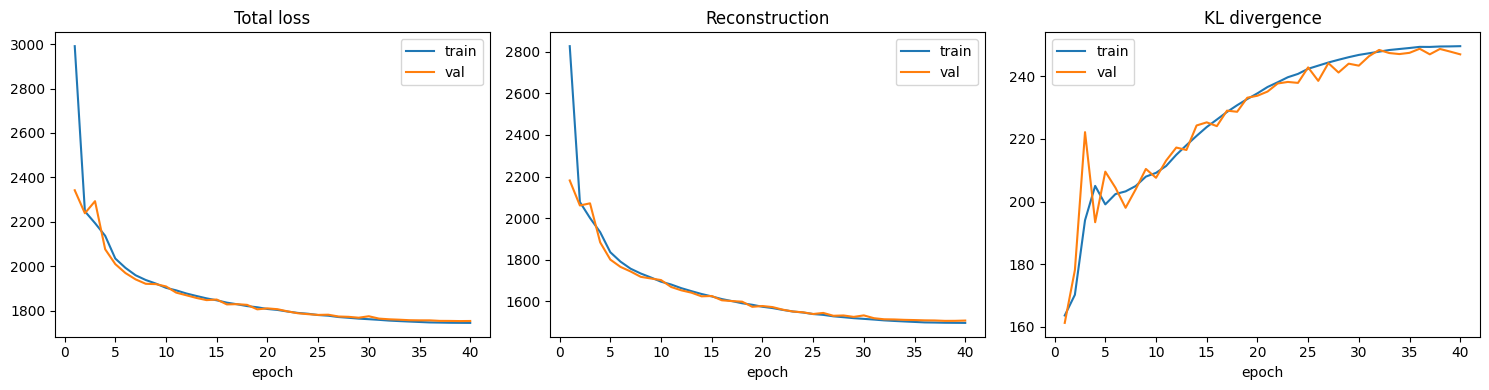

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train"]) + 1)
tr = history["train"]
va = history["val"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ["loss", "recon", "kld"],
                          ["Total loss", "Reconstruction", "KL divergence"]):
    ax.plot(epochs, [d[key] for d in tr], label="train")
    ax.plot(epochs, [d[key] for d in va], label="val")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout(); plt.savefig("vae_curves.png"); plt.show()

### Generation

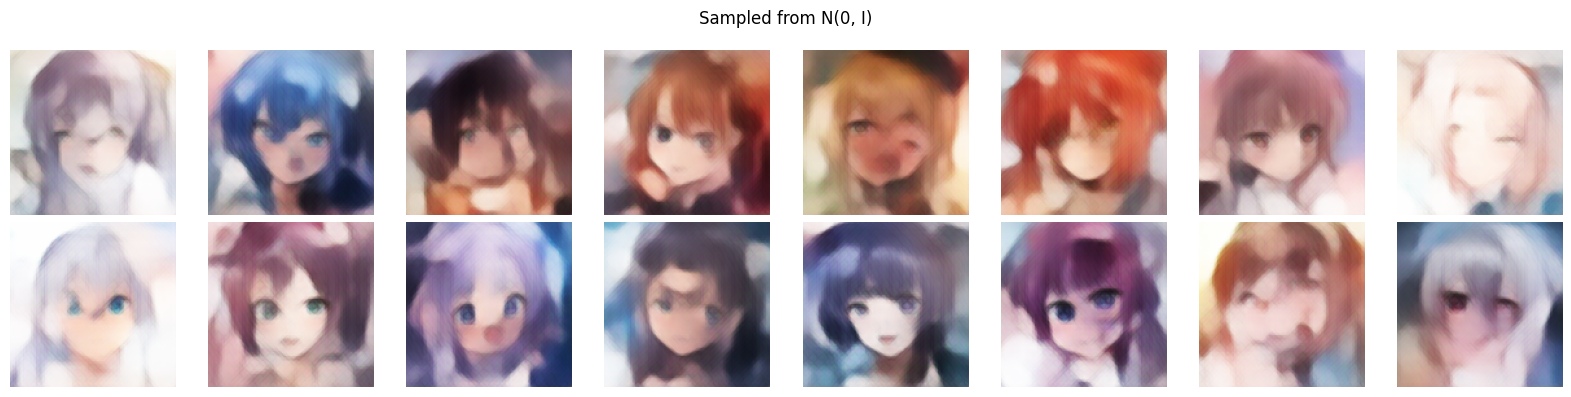

In [ ]:
import matplotlib.pyplot as plt

VAE_prcep_model.eval()
n = 16
with torch.no_grad():
    z = torch.randn(n, VAE_prcep_model.latent, device=device)
    gen = VAE_prcep_model.decode(z).cpu()                        # (n, 3, 128, 128) in [0,1]

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for img, ax in zip(gen, axes.flat):
    ax.imshow(img.permute(1, 2, 0))   # CHW -> HWC for RGB
    ax.axis("off")
plt.suptitle("Sampled from N(0, I)")
plt.tight_layout(); plt.savefig("vae_samples.png"); plt.show()

#### Bonus cell
generation using stats of latents

In [ ]:
import numpy as np

VAE_prcep_model.eval()
mus = []
with torch.no_grad():
    for x in train_loader:
        mu, _ = VAE_prcep_model.encode(x.to(device))
        mus.append(mu.cpu())
mus = torch.cat(mus, 0).numpy()          # (N, latent)

# --- full-covariance Gaussian fit ---
mean = torch.tensor(mus.mean(0), dtype=torch.float32)
cov  = torch.tensor(np.cov(mus, rowvar=False), dtype=torch.float32)
cov += 1e-4 * torch.eye(cov.size(0))     # jitter for numerical stability

dist = torch.distributions.MultivariateNormal(mean, covariance_matrix=cov)

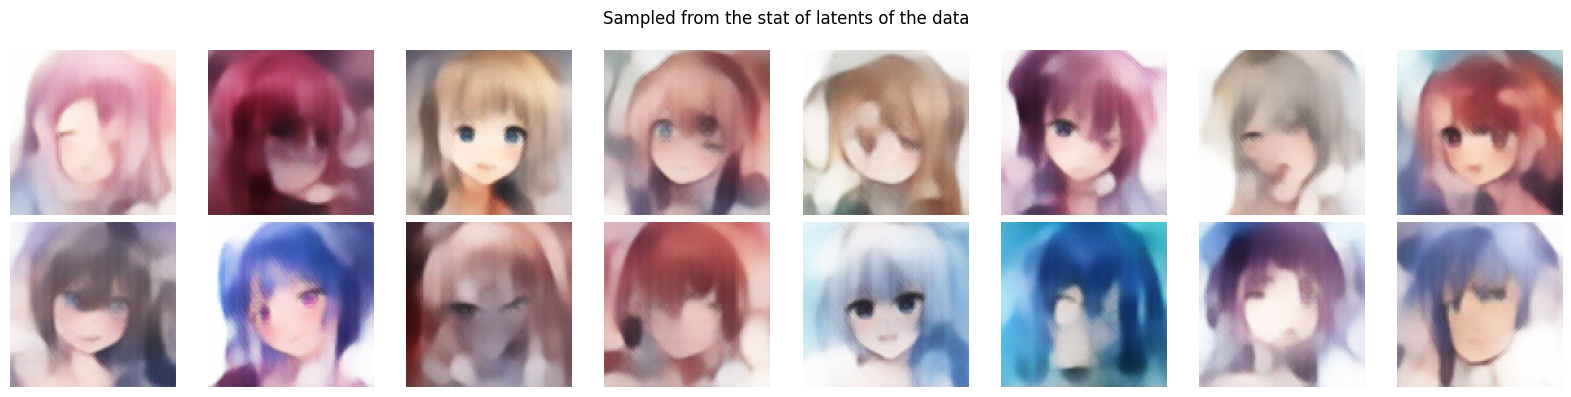

In [ ]:
with torch.no_grad():
    z = dist.sample((16,)).to(device)
    gen = VAE_prcep_model.decode(z).cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for img, ax in zip(gen, axes.flat):
    ax.imshow(img.permute(1, 2, 0))   # CHW -> HWC for RGB
    ax.axis("off")
plt.suptitle("Sampled from the stat of latents of the data")
plt.tight_layout(); plt.savefig("vae_samples.png"); plt.show()

## The VQ-VAE model

### Vector Quantizer (VQ) Module Architecture
To build the whole model, we first will build the piece that turns a latent Zₑ(x) to zq(x), meaning the piece that snaps codebook entries in their places.

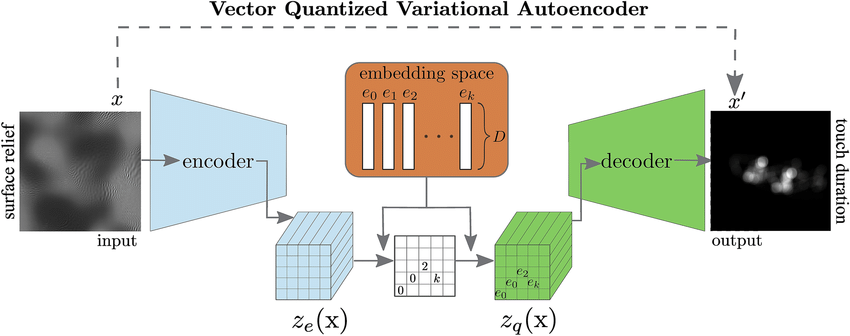



---

#### Dataflow Architecture

Data flows through the `forward` pass step-by-step as follows:

```text
 Continuous Input 'z' (Shape: [B, D, H, W])
           │
           ▼
     [Permute & Flatten] ──► Shape: [B*H*W, D] (Flat vectors)
           │
           ▼
┌────────────────────────────────────────────────────────┐
│ 1. NEAREST NEIGHBOR SEARCH                             │
│    • Calculate distance to all Codebook vectors.       │
│    • Find closest vector index per item.               │
└─────────────────────┬──────────────────────────────────┘
                      │
            ┌─────────┴─────────┐
            ▼                   ▼
    [Indices 'idx']        [One-Hot Representation]
     [B*H*W]                [B*H*W, n_codes]
            │                   │
            ▼                   ▼
┌──────────────────────┐  ┌──────────────────────┐
│ 2. QUANTIZATION      │  │ 3. EMA UPDATE        │
│    Look up vector in │  │    (If Training)     │
│    the Codebook      │  │ Update cluster sizes │
└───────────┬──────────┘  │ & codebook averages  │
            │             └──────────────────────┘
            ▼ Quantized 'q' [B, D, H, W]
┌────────────────────────────────────────────────────────┐
│ 4. STRAIGHT-THROUGH ESTIMATOR (STE)                    │
│    q = z + (q - z).detach()                            │
│    (Copies gradients from 'q' directly back to 'z')    │
└─────────────────────┬──────────────────────────────────┘
                      │
                      ▼
 Quantized Output 'q' & Metrics (vq_loss, perplexity)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class VectorQuantizer(nn.Module):
    def __init__(self, n_codes=256, dim=64, commit=0.25, decay=0.99, eps=1e-5,
             reset_every=200, reset_threshold=1.0):
        super().__init__()
        self.dim, self.commit, self.decay, self.eps, self.n_codes = dim, commit, decay, eps, n_codes

        # embeddings / codebook
        embed = torch.randn(n_codes, dim)

        self.register_buffer("embed", embed)
        self.register_buffer("cluster_size", torch.zeros(n_codes))
        self.register_buffer("embed_avg", embed.clone())

        # variables to reset dead codebook entries
        self.reset_every, self.reset_threshold = reset_every, reset_threshold
        self._step = 0

    @torch.no_grad()
    def _reset_dead_codes(self, flat):                    # flat: (BHW, D) encoder outputs
      dead = self.cluster_size < self.reset_threshold
      n_dead = int(dead.sum())
      if n_dead == 0:
          return

      # randomly select an embedding vector to replace one of the dead vectors
      pick = torch.randint(0, flat.size(0), (n_dead,), device=flat.device)
      new = flat[pick] + 1e-3 * torch.randn(n_dead, self.dim, device=flat.device)

      self.embed[dead] = new
      self.embed_avg[dead] = new
      self.cluster_size[dead] = 1.0


    def forward(self, z):                       # z: (B, D, H, W)
        B, D, H, W = z.shape
        flat = z.permute(0, 2, 3, 1).reshape(-1, D)

        # calculate distance from each feature vector and each codebook entry
        # but with a clever mathmatical trick :)
        d = flat.pow(2).sum(1, keepdim=True) - 2 * flat @ self.embed.t() + self.embed.pow(2).sum(1)
        idx = d.argmin(1)
        q = self.embed[idx].view(B, H, W, D).permute(0, 3, 1, 2)

        # we need onehot encoding to simplify EMA calculations
        onehot = F.one_hot(idx, self.n_codes).type(flat.dtype)

        if self.training:
              with torch.no_grad():
                # update codebook usage
                self.cluster_size.mul_(self.decay).add_(onehot.sum(0), alpha=1 - self.decay)

                #EMA: (B*EMA + (1-B)new embedding EMA) | updating codebook values
                self.embed_avg.mul_(self.decay).add_(onehot.t() @ flat, alpha=1 - self.decay)
                n = self.cluster_size.sum()
                cs = (self.cluster_size + self.eps) / (n + self.n_codes * self.eps) * n
                # move codebook entry to the average
                self.embed.copy_(self.embed_avg / cs.unsqueeze(1))

                self._step += 1
                if self.reset_every and (self._step % self.reset_every == 0):
                    self._reset_dead_codes(flat)

        commit_loss = F.mse_loss(z, q.detach())
        vq_loss = self.commit * commit_loss     # codebook is EMA-updated, so only the commit term remains
        q = z + (q - z).detach()                # straight-through

        # optional, to make it more verbose
        probs = onehot.mean(0)
        perplexity = torch.exp(-(probs * (probs + 1e-10).log()).sum())

        return q, vq_loss, perplexity

# VQ-VAE Sequential Data Flow Diagram

This diagram traces the step-by-step sequential execution order of tensors as they pass through each layer of the `VQVAE` module, assuming an input shape of `(Batch, 3, 128, 128)` and `dim=64`.

---

### 1. THE ENCODER
```text
Input Tensor: x ──► (B, 3, 128, 128)
  │
  ▼
[ down(3, 64) ]
  ├── Conv2d(3, 64, k=4, s=2, p=1) ───────────────────────────────► (B, 64, 64, 64)
  ├── ReLU() ─────────────────────────────────────────────────────► (B, 64, 64, 64)
  ├── ResBlock1 ──► [ x + Conv1x1(ReLU(Conv3x3(ReLU(x)))) ] ──────► (B, 64, 64, 64)
  └── ResBlock2 ──► [ x + Conv1x1(ReLU(Conv3x3(ReLU(x)))) ] ──────► (B, 64, 64, 64)
  │
  ▼
[ down(64, 128) ]
  ├── Conv2d(64, 128, k=4, s=2, p=1) ─────────────────────────────► (B, 128, 32, 32)
  ├── ReLU() ─────────────────────────────────────────────────────► (B, 128, 32, 32)
  ├── ResBlock3 ──► [ x + Conv1x1(ReLU(Conv3x3(ReLU(x)))) ] ──────► (B, 128, 32, 32)
  └── ResBlock4 ──► [ x + Conv1x1(ReLU(Conv3x3(ReLU(x)))) ] ──────► (B, 128, 32, 32)
  │
  ▼
[ Encoder Bottleneck ]
  ├── Conv2d(128, dim, k=3, s=1, p=1) ────────────────────────────► (B, dim, 32, 32)
  ├── ResBlock5 ──► [ x + Conv1x1(ReLU(Conv3x3(ReLU(x)))) ] ──────► (B, dim, 32, 32)
  └── ResBlock6 ──► [ x + Conv1x1(ReLU(Conv3x3(ReLU(x)))) ] ──────► (B, dim, 32, 32)

# Decoder Data Flow Diagram

This diagram traces the step-by-step sequential execution order of tensors through the `self.decoder` module, assuming an input shape of `(Batch, dim, 32, 32)`.

---



```text
Quantized Tensor: q ──► (B, dim, 32, 32)
  │
  ▼
[ Decoder Bottleneck ]
  ├── ResBlock1 ──► [ x + Conv1x1(ReLU(Conv3x3(ReLU(x)))) ] ──────► (B, dim, 32, 32)
  ├── ResBlock2 ──► [ x + Conv1x1(ReLU(Conv3x3(ReLU(x)))) ] ──────► (B, dim, 32, 32)
  ├── ReLU() ─────────────────────────────────────────────────────► (B, dim, 32, 32)
  ├── Conv2d(dim, 128, k=3, s=1, p=1) ────────────────────────────► (B, 128, 32, 32)
  └── ReLU() ─────────────────────────────────────────────────────► (B, 128, 32, 32)
  │
  ▼
[ up(128, 64) ]
  ├── ConvTranspose2d(128, 64, k=4, s=2, p=1) ────────────────────► (B, 64, 64, 64)
  ├── ReLU() ─────────────────────────────────────────────────────► (B, 64, 64, 64)
  ├── ResBlock3  ──► [ x + Conv1x1(ReLU(Conv3x3(ReLU(x)))) ] ─────► (B, 64, 64, 64)
  └── ResBlock4 ──► [ x + Conv1x1(ReLU(Conv3x3(ReLU(x)))) ] ─────► (B, 64, 64, 64)
  │
  ▼
[ Output Projection ]
  ├── ConvTranspose2d(64, 3, k=4, s=2, p=1) ──────────────────────► (B, 3, 128, 128)
  └── Sigmoid() ──────────────────────────────────────────────────► (B, 3, 128, 128)

Output Tensor: (B, 3, 128, 128)

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.ReLU(), nn.Conv2d(c, c, 3, padding=1),
            nn.ReLU(), nn.Conv2d(c, c, 1),
        )
    def forward(self, x): return x + self.net(x)


class VQVAE(nn.Module):
    def __init__(self, dim=64, n_codes=512):
        super().__init__()

        def down(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 4, stride=2, padding=1),
                nn.ReLU(), ResBlock(cout), ResBlock(cout),   # refine at this resolution
            )

        def up(cin, cout):
            return nn.Sequential(
                nn.ConvTranspose2d(cin, cout, 4, stride=2, padding=1),
                nn.ReLU(), ResBlock(cout), ResBlock(cout),   # refine at this resolution
            )

        self.encoder = nn.Sequential(
            down(3, 64),                                     # 128 -> 64
            down(64, 128),                                   # 64  -> 32
            nn.Conv2d(128, dim, 3, stride=1, padding=1),     # 32  -> 32 (grid-preserving)
            ResBlock(dim), ResBlock(dim),
        )
        self.vq = VectorQuantizer(n_codes, dim)
        self.decoder = nn.Sequential(
            ResBlock(dim), ResBlock(dim), nn.ReLU(),
            nn.Conv2d(dim, 128, 3, stride=1, padding=1), nn.ReLU(),  # mirror the 3/1/1 bottleneck
            up(128, 64),                                    # 32 -> 64, then refine
            nn.ConvTranspose2d(64, 3, 4, stride=2, padding=1), nn.Sigmoid(),  # 64 -> 128
        )

    def forward(self, x):
        z = self.encoder(x)
        q, vq_loss, perplexity = self.vq(z)
        return self.decoder(q), vq_loss, perplexity


In [ ]:
def vqvae_loss(recon, x, vq_loss):
    recon_loss = F.mse_loss(recon, x)
    return recon_loss + vq_loss, recon_loss

#### yet another train / eval loop

In [ ]:
from tqdm import tqdm

def train_one_epoch_vq(model, loader, optimizer, device):
    model.train()
    totals = {"loss": 0.0, "recon": 0.0, "perp": 0.0}
    n = 0
    pbar = tqdm(loader, desc="train", leave=False)
    for x in pbar:
        x = x.to(device)
        recon, vq_loss, perplexity = model(x)
        loss, recon_l = vqvae_loss(recon, x, vq_loss)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        totals["loss"]  += loss.item()       * bs
        totals["recon"] += recon_l.item()    * bs
        totals["perp"]  += perplexity.item() * bs
        n += bs
        pbar.set_postfix(loss=loss.item(), perp=perplexity.item())
    return {k: v / n for k, v in totals.items()}


@torch.no_grad()
def eval_one_epoch_vq(model, loader, device):
    model.eval()
    totals = {"loss": 0.0, "recon": 0.0, "perp": 0.0}
    n = 0
    pbar = tqdm(loader, desc="eval", leave=False)
    for x in pbar:
        x = x.to(device)
        recon, vq_loss, perplexity = model(x)
        loss, recon_l = vqvae_loss(recon, x, vq_loss)
        bs = x.size(0)
        totals["loss"]  += loss.item()       * bs
        totals["recon"] += recon_l.item()    * bs
        totals["perp"]  += perplexity.item() * bs
        n += bs
        pbar.set_postfix(loss=loss.item())
    return {k: v / n for k, v in totals.items()}

### Training

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 30
history = {"train": [], "val": []}

n_codes=256*4
vqvae = VQVAE(n_codes=n_codes, dim=64*2).to(device)
optimizer = torch.optim.AdamW(vqvae.parameters(), lr=2e-4)   # VQ likes a lower LR than the VAE
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(1, EPOCHS + 1):
    tr = train_one_epoch_vq(vqvae, train_loader, optimizer, device)
    va = eval_one_epoch_vq(vqvae, val_loader, device)
    history["train"].append(tr); history["val"].append(va)

    scheduler.step()

    print(f"epoch {epoch:2d}/{EPOCHS} | "
          f"train {tr['loss']:.4f} (recon {tr['recon']:.4f}) perp {tr['perp']:.1f} | "
          f"val {va['loss']:.4f} perp {va['perp']:.1f}")

torch.save(vqvae.state_dict(), "vqvae_anime.pth")
print("saved -> vqvae_anime.pth")

epoch  1/30 | train 0.0559 (recon 0.0500) perp 1.8 | val 0.0429 perp 1.8


epoch  2/30 | train 0.0229 (recon 0.0215) perp 86.9 | val 0.0126 perp 40.3


epoch  3/30 | train 0.0088 (recon 0.0084) perp 326.3 | val 0.0070 perp 451.4


epoch  4/30 | train 0.0067 (recon 0.0065) perp 562.7 | val 0.0062 perp 708.8


epoch  5/30 | train 0.0061 (recon 0.0059) perp 728.4 | val 0.0058 perp 763.8


...

epoch 26/30 | train 0.0024 (recon 0.0021) perp 911.5 | val 0.0024 perp 905.8


epoch 27/30 | train 0.0024 (recon 0.0021) perp 905.0 | val 0.0024 perp 899.6


epoch 28/30 | train 0.0024 (recon 0.0021) perp 898.1 | val 0.0024 perp 892.5


epoch 29/30 | train 0.0024 (recon 0.0021) perp 891.5 | val 0.0024 perp 885.7


epoch 30/30 | train 0.0024 (recon 0.0021) perp 884.9 | val 0.0024 perp 878.8
saved -> vqvae_anime.pth


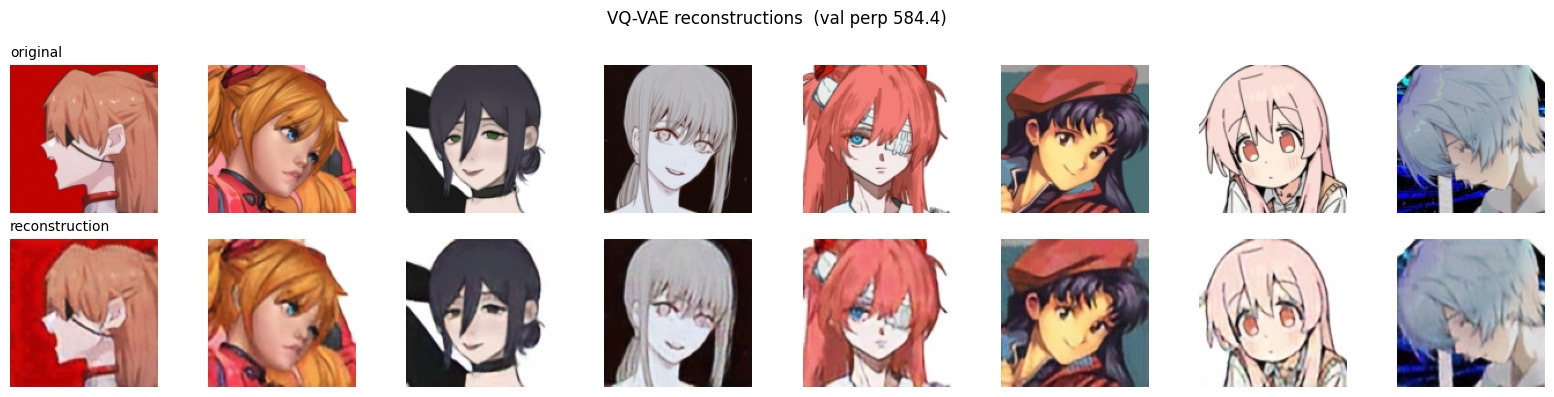

In [ ]:
import matplotlib.pyplot as plt
vqvae.eval()
n = 8
with torch.no_grad():
    x = next(iter(val_loader))[n*2:n*3].to(device)      # held-out images
    recon, vq_loss, perp = vqvae(x)
    x, recon = x.cpu(), recon.cpu()

fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))
for i in range(n):
    axes[0, i].imshow(x[i].permute(1, 2, 0).clamp(0, 1));     axes[0, i].axis("off")
    axes[1, i].imshow(recon[i].permute(1, 2, 0).clamp(0, 1)); axes[1, i].axis("off")
axes[0, 0].set_title("original", loc="left", fontsize=10)
axes[1, 0].set_title("reconstruction", loc="left", fontsize=10)
plt.suptitle(f"VQ-VAE reconstructions  (val perp {perp:.1f})")
plt.tight_layout(); plt.show()

### Generation

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F

class CodeTransformer(nn.Module):
    def __init__(self, n_codes=256, seq_len=256, d=256, heads=8, layers=6):
        super().__init__()
        self.seq_len = seq_len
        self.tok = nn.Embedding(n_codes + 1, d)      # +1 for a start token
        self.pos = nn.Parameter(torch.zeros(1, seq_len, d))
        block = nn.TransformerEncoderLayer(d, heads, d * 4, batch_first=True,
                                           activation="gelu", norm_first=True)
        self.blocks = nn.TransformerEncoder(block, layers)
        self.head = nn.Linear(d, n_codes)
        self.start = n_codes                          # id of the start token

    def forward(self, x):                             # x: (B, seq_len) code indices
        B = x.size(0)
        start = torch.full((B, 1), self.start, device=x.device)
        inp = torch.cat([start, x[:, :-1]], 1)        # shift right: predict token t from <t
        h = self.tok(inp) + self.pos
        mask = torch.triu(torch.ones(self.seq_len, self.seq_len, device=x.device), 1).bool()
        h = self.blocks(h, mask=mask)
        return self.head(h)                           # (B, seq_len, n_codes)

In [ ]:
@torch.no_grad()
def encode_indices(vqvae, loader, device):
    vqvae.eval()
    all_idx = []
    for x in loader:
        z = vqvae.encoder(x.to(device))
        B, D, H, W = z.shape
        flat = z.permute(0, 2, 3, 1).reshape(-1, D)
        idx = torch.cdist(flat, vqvae.vq.embed).argmin(1)  # nearest code (EMA codebook = .embed)
        all_idx.append(idx.view(B, H * W).cpu())                     # (B, 256)
    return torch.cat(all_idx, 0)

train_codes = encode_indices(vqvae, train_loader, device)   # (N, 256), ints in [0,512)
GRID = 32 #put ur grid size here

In [ ]:
codes_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(train_codes), batch_size=512, shuffle=True)
EPOCHS = 50

current_seq_len = train_codes.size(1)
model = CodeTransformer(n_codes=n_codes, seq_len=current_seq_len).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

for epoch in range(1, EPOCHS):
    model.train(); total = 0
    for (batch,) in tqdm(codes_loader):
        batch = batch.to(device)
        logits = model(batch)

        loss = F.cross_entropy(logits.reshape(-1, n_codes), batch.reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * batch.size(0)

    scheduler.step()
    print(f"epoch {epoch:2d} | ce {total/len(train_codes):.4f}")

/tmp/ipykernel_1216/1872500613.py:11: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(block, layers)
100%|██████████| 85/85 [00:03<00:00, 22.78it/s]


epoch  1 | ce 6.8648


100%|██████████| 85/85 [00:03<00:00, 24.28it/s]


epoch  2 | ce 6.5118


100%|██████████| 85/85 [00:03<00:00, 24.28it/s]


...

epoch 47 | ce 5.7356


100%|██████████| 85/85 [00:03<00:00, 24.22it/s]


epoch 48 | ce 5.7343


100%|██████████| 85/85 [00:03<00:00, 24.22it/s]

epoch 49 | ce 5.7346


In [ ]:
@torch.no_grad()
def generate(model, vqvae, n=8, temp=0.9, top_k=40):
    model.eval(); vqvae.eval()
    seq = torch.empty(n, 0, dtype=torch.long, device=device)
    for t in range(model.seq_len):
        pad = torch.zeros(n, model.seq_len - seq.size(1), dtype=torch.long, device=device)
        logits = model(torch.cat([seq, pad], 1))[:, t, :] / temp   # next-token logits
        if top_k:
            v, _ = logits.topk(top_k)
            logits[logits < v[:, [-1]]] = -float("inf")
        probs = F.softmax(logits, -1)
        seq = torch.cat([seq, torch.multinomial(probs, 1)], 1)
    # indices -> code vectors -> image
    codes = vqvae.vq.embed[seq]                     # (n, 256, D)
    z = codes.view(n, GRID, GRID, -1).permute(0, 3, 1, 2)
    imgs = vqvae.decoder(z).cpu()
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2))
    for img, ax in zip(imgs, axes):
        ax.imshow(img.permute(1, 2, 0).clamp(0, 1)); ax.axis("off")
    plt.show()

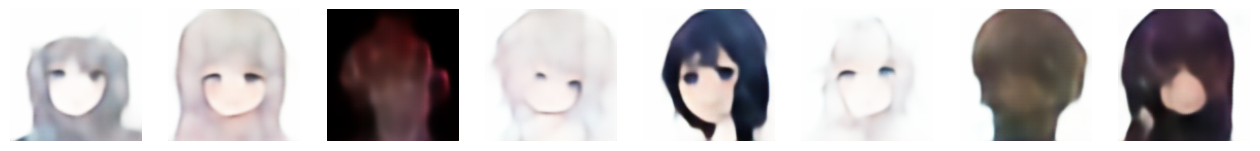

In [ ]:
generate(model, vqvae) # @ grid = 8x8

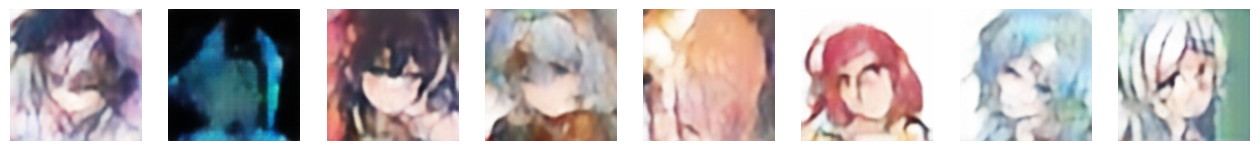

In [ ]:
generate(model, vqvae) # @ grid = 16x16 very low training epochs

### Made by:

#### [Muhannad](https://www.linkedin.com/in/muhannad-alhumaidi-a617b4309/)
<img src="https://drive.google.com/uc?id=13epx2b2TppyWuPunpteJ4nj5MOM1WbFJ" width="100" height="100"/>

#### [Anas](https://github.com/AnasKAN)
<img src="https://drive.google.com/uc?id=1sRRSwuPqoVpdVmM5xZ88kbShTI_RvE_1" width="100" height="100"/>